<a href="https://colab.research.google.com/github/hodatisg520/DL4AI-240112-project/blob/main/Final_project_DL4AI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Final project: Time-series data and application to stock markets {-}

This project aims at familiarizing you with time-series data analysis and its application to stock markets. Datasets you will be working on are Nasdaq and Vietnam stock datasets.

### Submission {-}
The structure of submission folder should be organized as follows:

- ./\<StudentID>-project-notebook.ipynb: Jupyter notebook containing source code.
- ./\<StudentID>-project-report.pdf: project report.

The submission folder is named DL4AI-\<StudentID>-project (e.g., DL4AI-2012345-project) and then compressed with the same name.
    
### Evaluation {-}
Project evaluation will be conducted on how you accomplish the assignment requirements. You can refer to the project instruction slide deck for details.

### Deadline {-}
Please visit Canvas for details.

In [ ]:
# Your code goes here

# TASK 1

## 1.1

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM
from tensorflow.keras.callbacks import EarlyStopping  # [Fix 1] thêm import EarlyStopping
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error  # [Fix 6] thêm mean_absolute_error

In [ ]:
# 1. Hàm tạo dataset (Cập nhật từ mẫu để nhận đa biến)
def create_dataset(dataset, time_step=1, target_idx=2):
    dataX, dataY = [], []
    for i in range(len(dataset) - time_step):  # [Fix 3] bỏ '- 1' để không mất sample cuối
        # Lấy toàn bộ các cột (features) trong cửa sổ thời gian
        a = dataset[i:(i + time_step), :]
        dataX.append(a)
        # Chỉ lấy 1 cột mục tiêu để dự đoán (ví dụ cột Open - index 2)
        dataY.append(dataset[i + time_step, target_idx])
    return np.array(dataX), np.array(dataY)

In [ ]:
# 2. Đọc dữ liệu
from google.colab import drive
drive.mount('/content/drive')
file_path = '/content/drive/MyDrive/AAL.csv'
df = pd.read_csv(file_path)
# Lấy 6 đặc trưng theo yêu cầu Task 1.1
features = ['Low', 'High', 'Open', 'Close', 'Adjusted Close', 'Volume']
dataset = df[features].values
dataset = dataset.astype('float32')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# 3. Chia Train/Test trước khi Scale
train_size = int(len(dataset) * 0.8)
test_size = len(dataset) - train_size
train, test = dataset[0:train_size,:], dataset[train_size:len(dataset),:]

In [ ]:
# 4. Chuẩn hóa dữ liệu (Scaling)
scaler = MinMaxScaler(feature_range=(0, 1))
train = scaler.fit_transform(train)
test = scaler.transform(test)

# Scaler riêng cho cột Target để inverse_transform sau này
target_scaler = MinMaxScaler(feature_range=(0, 1))
target_scaler.fit(dataset[0:train_size, 2].reshape(-1, 1)) # Cột Open

# [Fix 4] Ghép time_step ngày cuối của train vào đầu test
# để testX[0] có context liền mạch từ dữ liệu train thực sự
time_step = 60

In [ ]:
# 5. Tạo tập dữ liệu Train/Test
target_col_idx = 2 # Dự đoán giá Open
trainX, trainY = create_dataset(train, time_step, target_col_idx)
testX, testY = create_dataset(test, time_step, target_col_idx)  # [Fix 4] dùng test_with_context

In [ ]:
# 6. Xây dựng mô hình LSTM (Đúng cấu trúc Sequential trong ảnh)
model = Sequential()
# input_shape=(time_step, 6) vì ta có 6 đặc trưng đầu vào
model.add(LSTM(50, input_shape=(time_step, 6)))
model.add(Dense(1))
model.compile(loss='mean_squared_error', optimizer='adam')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
# 7. Huấn luyện
# [Fix 1] Thêm validation_split và EarlyStopping để tránh overfit
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)
model.fit(trainX, trainY, epochs=100, batch_size=32,
          validation_split=0.1, callbacks=[early_stop], verbose=2)

Epoch 1/100
96/96 - 6s - 65ms/step - loss: 0.0114 - val_loss: 0.0011
Epoch 2/100
96/96 - 2s - 23ms/step - loss: 4.9195e-04 - val_loss: 6.8888e-04
Epoch 3/100
96/96 - 2s - 23ms/step - loss: 4.5083e-04 - val_loss: 9.0525e-04
Epoch 4/100
96/96 - 2s - 23ms/step - loss: 4.3139e-04 - val_loss: 5.3845e-04
Epoch 5/100
96/96 - 4s - 43ms/step - loss: 3.8600e-04 - val_loss: 5.8760e-04
Epoch 6/100
96/96 - 3s - 28ms/step - loss: 3.5371e-04 - val_loss: 6.1778e-04
Epoch 7/100
96/96 - 2s - 23ms/step - loss: 3.2859e-04 - val_loss: 3.9647e-04
Epoch 8/100
96/96 - 3s - 27ms/step - loss: 3.0367e-04 - val_loss: 5.3255e-04
Epoch 9/100
96/96 - 2s - 23ms/step - loss: 2.7751e-04 - val_loss: 2.6677e-04
Epoch 10/100
96/96 - 3s - 27ms/step - loss: 2.5486e-04 - val_loss: 4.8512e-04
Epoch 11/100
96/96 - 4s - 38ms/step - loss: 2.4872e-04 - val_loss: 2.2082e-04
Epoch 12/100
96/96 - 2s - 25ms/step - loss: 2.3171e-04 - val_loss: 5.5145e-04
Epoch 13/100
96/96 - 2s - 23ms/step - loss: 2.2288e-04 - val_loss: 2.7882e-04
Epo

In [ ]:
# 8. Dự đoán và đưa về đơn vị giá thực tế
trainPredict = model.predict(trainX)
testPredict = model.predict(testX)

# Get prediction on the test data (Dự đoán trên tập test đã chuẩn hóa)
y_pred_norm = model.predict(testX)

# Tính và in ra MSE trên tập test (đã chuẩn hóa) theo đúng sample code
print("MSE on the test set: ", mean_squared_error(y_pred_norm, testY))
trainPredict = target_scaler.inverse_transform(trainPredict)
testPredict = target_scaler.inverse_transform(testPredict)

# [Fix 6] Tính thêm MAE, RMSE, MAPE trên giá thực tế
testY_real = target_scaler.inverse_transform(testY.reshape(-1, 1))
mae  = mean_absolute_error(testY_real, testPredict)
rmse = np.sqrt(mean_squared_error(testY_real, testPredict))
mape = np.mean(np.abs((testY_real - testPredict) / testY_real)) * 100
print(f"MAE  on the test set: {mae:.4f} USD")
print(f"RMSE on the test set: {rmse:.4f} USD")
print(f"MAPE on the test set: {mape:.2f}%")

107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
MSE on the test set:  9.583633800502867e-05
MAE  on the test set: 0.3809 USD
RMSE on the test set: 0.5961 USD
MAPE on the test set: 2.38%


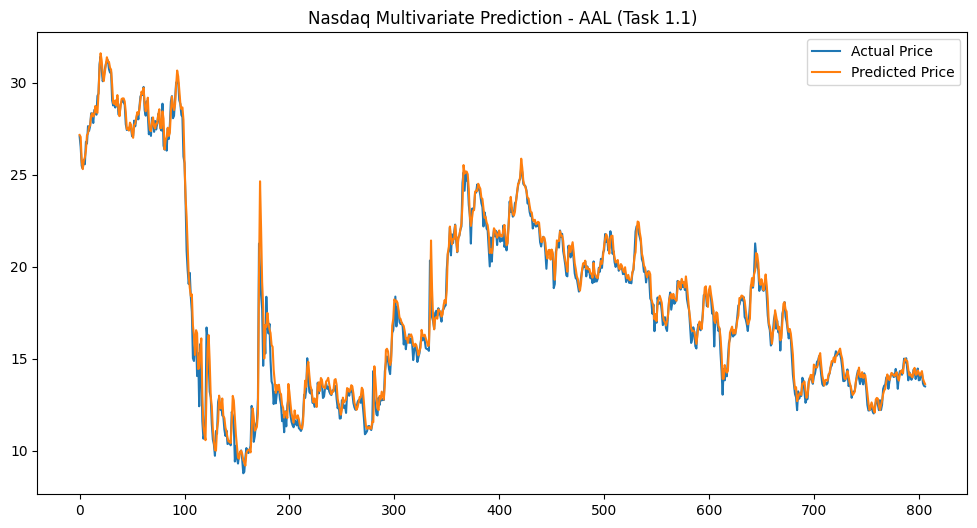

In [ ]:
# 9. Vẽ biểu đồ so sánh (Theo phong cách ảnh mẫu)
testY_plot = target_scaler.inverse_transform(testY.reshape(-1, 1))

plt.figure(figsize=(12,6))
plt.plot(testY_plot, label='Actual Price')
plt.plot(testPredict, label='Predicted Price')
plt.title('Nasdaq Multivariate Prediction - AAL (Task 1.1)')  # [Fix 5] thêm tên ticker AAL
plt.legend()
plt.show()

## 1.2

In [ ]:
def create_dataset_multivariate(dataset, time_step=1, target_idx=2, k=1):
    dataX, dataY = [], []
    # Điều chỉnh vòng lặp để lấy nhãn ở ngày thứ k
    for i in range(len(dataset) - time_step - k + 1):
        # Lấy X (vẫn là cửa sổ 60 ngày)
        a = dataset[i:(i + time_step), :]
        dataX.append(a)
        # Lấy Y (là giá trị tại ngày thứ k sau cửa sổ X)
        dataY.append(dataset[i + time_step + k - 1, target_idx])
    return np.array(dataX), np.array(dataY)

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


96/96 - 7s - 70ms/step - loss: 0.0046 - val_loss: 0.0016
Epoch 2/100
96/96 - 5s - 56ms/step - loss: 8.1765e-04 - val_loss: 9.7291e-04
Epoch 3/100
96/96 - 7s - 74ms/step - loss: 7.7241e-04 - val_loss: 7.9282e-04
Epoch 4/100
96/96 - 2s - 24ms/step - loss: 7.3340e-04 - val_loss: 7.4537e-04
Epoch 5/100
96/96 - 2s - 26ms/step - loss: 7.2421e-04 - val_loss: 8.7574e-04
Epoch 6/100
96/96 - 2s - 23ms/step - loss: 6.7018e-04 - val_loss: 9.0894e-04
Epoch 7/100
96/96 - 3s - 35ms/step - loss: 7.0158e-04 - val_loss: 6.4484e-04
Epoch 8/100
96/96 - 3s - 33ms/step - loss: 6.2713e-04 - val_loss: 7.9515e-04
Epoch 9/100
96/96 - 2s - 23ms/step - loss: 6.1978e-04 - val_loss: 6.1841e-04
Epoch 10/100
96/96 - 3s - 28ms/step - loss: 5.9561e-04 - val_loss: 6.7657e-04
Epoch 11/100
96/96 - 2s - 23ms/step - loss: 5.9433e-04 - val_loss: 6.2171e-04
Epoch 12/100
96/96 - 2s - 26ms/step - loss: 5.9571e-04 - val_loss: 7.8213e-04
Epoch 13/100
96/96 - 5s - 50ms/step - loss: 5.7634e-04 - val_loss: 6.6389e-04
Epoch 14/100
96

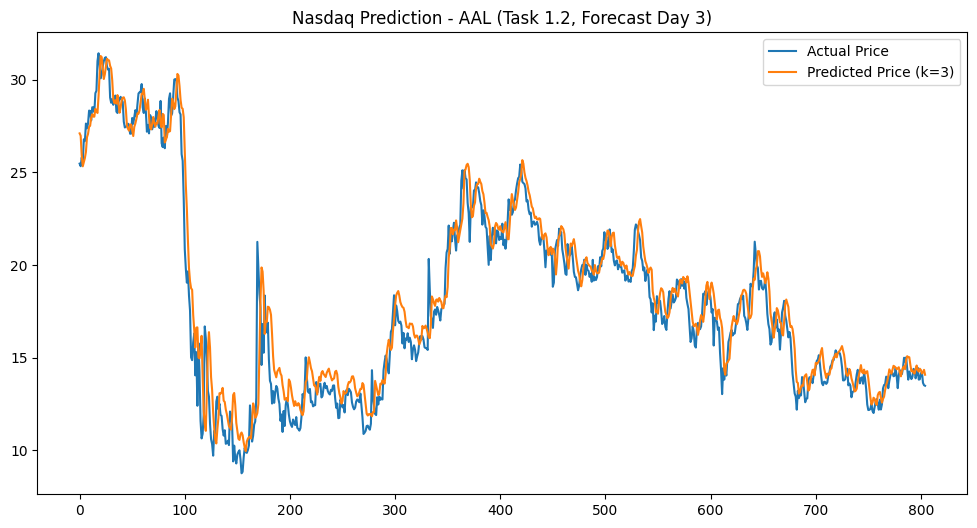

In [ ]:
# 1. Cấu hình k cho Task 1.2 (ví dụ k=3)
k_days = 3
# Sử dụng lại các biến 'train', 'time_step' và 'target_scaler' đã có từ Task 1.1

# 2. Tạo tập dữ liệu mới cho ngày thứ k
trainX_k, trainY_k = create_dataset_multivariate(train, time_step, target_idx=2, k=k_days)
testX_k, testY_k = create_dataset_multivariate(test, time_step, target_idx=2, k=k_days)  # [Fix 4]

# 3. Xây dựng mô hình mới (đặt tên model_k để tránh ghi đè model cũ)
model_k = Sequential()
model_k.add(LSTM(50, input_shape=(time_step, 6)))
model_k.add(Dense(1))
model_k.compile(loss='mean_squared_error', optimizer='adam')

# 4. Huấn luyện
# [Fix 1] Thêm validation_split và EarlyStopping
early_stop_k3 = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)
model_k.fit(trainX_k, trainY_k, epochs=100, batch_size=32,
            validation_split=0.1, callbacks=[early_stop_k3], verbose=2)

# 5. Dự đoán và đánh giá MSE trên tập test (chuẩn hóa)
y_pred_norm_k = model_k.predict(testX_k)
print(f"MSE on the test set (Normalized, k={k_days}): ", mean_squared_error(y_pred_norm_k, testY_k))

# 6. Giải mã giá thực tế và vẽ biểu đồ
y_test_real_k = target_scaler.inverse_transform(testY_k.reshape(-1, 1))
y_pred_real_k = target_scaler.inverse_transform(y_pred_norm_k)

# [Fix 6] Tính thêm MAE, RMSE, MAPE
mae_k  = mean_absolute_error(y_test_real_k, y_pred_real_k)
rmse_k = np.sqrt(mean_squared_error(y_test_real_k, y_pred_real_k))
mape_k = np.mean(np.abs((y_test_real_k - y_pred_real_k) / y_test_real_k)) * 100
print(f"MAE  on the test set (k={k_days}): {mae_k:.4f} USD")
print(f"RMSE on the test set (k={k_days}): {rmse_k:.4f} USD")
print(f"MAPE on the test set (k={k_days}): {mape_k:.2f}%")

plt.figure(figsize=(12,6))
plt.plot(y_test_real_k, label='Actual Price')
plt.plot(y_pred_real_k, label=f'Predicted Price (k={k_days})')
plt.title(f'Nasdaq Prediction - AAL (Task 1.2, Forecast Day {k_days})')  # [Fix 5] thêm AAL
plt.legend()
plt.show()

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


96/96 - 6s - 64ms/step - loss: 0.0072 - val_loss: 0.0025
Epoch 2/100
96/96 - 4s - 45ms/step - loss: 0.0016 - val_loss: 0.0017
Epoch 3/100
96/96 - 3s - 26ms/step - loss: 0.0015 - val_loss: 0.0018
Epoch 4/100
96/96 - 3s - 30ms/step - loss: 0.0015 - val_loss: 0.0016
Epoch 5/100
96/96 - 4s - 40ms/step - loss: 0.0015 - val_loss: 0.0022
Epoch 6/100
96/96 - 2s - 24ms/step - loss: 0.0015 - val_loss: 0.0015
Epoch 7/100
96/96 - 3s - 28ms/step - loss: 0.0014 - val_loss: 0.0020
Epoch 8/100
96/96 - 3s - 31ms/step - loss: 0.0014 - val_loss: 0.0020
Epoch 9/100
96/96 - 3s - 28ms/step - loss: 0.0014 - val_loss: 0.0015
Epoch 10/100
96/96 - 4s - 39ms/step - loss: 0.0014 - val_loss: 0.0015
Epoch 11/100
96/96 - 2s - 25ms/step - loss: 0.0014 - val_loss: 0.0018
Epoch 12/100
96/96 - 2s - 24ms/step - loss: 0.0014 - val_loss: 0.0024
Epoch 13/100
96/96 - 2s - 23ms/step - loss: 0.0014 - val_loss: 0.0016
Epoch 14/100
96/96 - 2s - 24ms/step - loss: 0.0014 - val_loss: 0.0017
Epoch 15/100
96/96 - 4s - 37ms/step - los

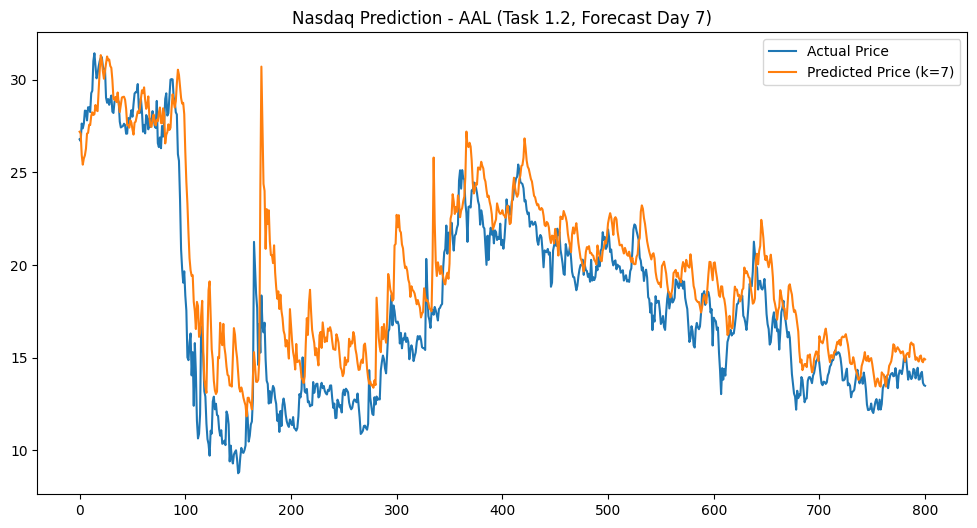

In [ ]:
# 1. Cấu hình k cho Task 1.2 (ví dụ k=7)
k_days = 7
# Sử dụng lại các biến 'train', 'time_step' và 'target_scaler' đã có từ Task 1.1

# 2. Tạo tập dữ liệu mới cho ngày thứ k
trainX_k, trainY_k = create_dataset_multivariate(train, time_step, target_idx=2, k=k_days)
testX_k, testY_k = create_dataset_multivariate(test, time_step, target_idx=2, k=k_days)  # [Fix 4]

# 3. Xây dựng mô hình mới (đặt tên model_k để tránh ghi đè model cũ)
model_k = Sequential()
model_k.add(LSTM(50, input_shape=(time_step, 6)))
model_k.add(Dense(1))
model_k.compile(loss='mean_squared_error', optimizer='adam')

# 4. Huấn luyện
# [Fix 1] Thêm validation_split và EarlyStopping
early_stop_k7 = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)
model_k.fit(trainX_k, trainY_k, epochs=100, batch_size=32,
            validation_split=0.1, callbacks=[early_stop_k7], verbose=2)

# 5. Dự đoán và đánh giá MSE trên tập test (chuẩn hóa)
y_pred_norm_k = model_k.predict(testX_k)
print(f"MSE on the test set (Normalized, k={k_days}): ", mean_squared_error(y_pred_norm_k, testY_k))

# 6. Giải mã giá thực tế và vẽ biểu đồ
y_test_real_k = target_scaler.inverse_transform(testY_k.reshape(-1, 1))
y_pred_real_k = target_scaler.inverse_transform(y_pred_norm_k)

# [Fix 6] Tính thêm MAE, RMSE, MAPE
mae_k  = mean_absolute_error(y_test_real_k, y_pred_real_k)
rmse_k = np.sqrt(mean_squared_error(y_test_real_k, y_pred_real_k))
mape_k = np.mean(np.abs((y_test_real_k - y_pred_real_k) / y_test_real_k)) * 100
print(f"MAE  on the test set (k={k_days}): {mae_k:.4f} USD")
print(f"RMSE on the test set (k={k_days}): {rmse_k:.4f} USD")
print(f"MAPE on the test set (k={k_days}): {mape_k:.2f}%")

plt.figure(figsize=(12,6))
plt.plot(y_test_real_k, label='Actual Price')
plt.plot(y_pred_real_k, label=f'Predicted Price (k={k_days})')
plt.title(f'Nasdaq Prediction - AAL (Task 1.2, Forecast Day {k_days})')  # [Fix 5] thêm AAL
plt.legend()
plt.show()

## 1.3

In [ ]:
def create_dataset_sequence(dataset, time_step=60, target_idx=2, k=3):
    dataX, dataY = [], []
    for i in range(len(dataset) - time_step - k + 1):
        # X: Lấy cửa sổ thời gian như bình thường (ví dụ 60 ngày)
        a = dataset[i:(i + time_step), :]
        dataX.append(a)

        # Y: Lấy một mảng liên tục k ngày tiếp theo
        dataY.append(dataset[i + time_step : i + time_step + k, target_idx])

    return np.array(dataX), np.array(dataY)

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


96/96 - 6s - 62ms/step - loss: 0.0210 - val_loss: 0.0013
Epoch 2/100
96/96 - 2s - 24ms/step - loss: 9.4579e-04 - val_loss: 0.0016
Epoch 3/100
96/96 - 2s - 23ms/step - loss: 8.9237e-04 - val_loss: 0.0010
Epoch 4/100
96/96 - 3s - 27ms/step - loss: 8.2974e-04 - val_loss: 0.0013
Epoch 5/100
96/96 - 2s - 24ms/step - loss: 7.7116e-04 - val_loss: 9.3028e-04
Epoch 6/100
96/96 - 4s - 39ms/step - loss: 6.9820e-04 - val_loss: 8.9993e-04
Epoch 7/100
96/96 - 3s - 28ms/step - loss: 6.4131e-04 - val_loss: 7.0831e-04
Epoch 8/100
96/96 - 5s - 49ms/step - loss: 6.4420e-04 - val_loss: 6.3902e-04
Epoch 9/100
96/96 - 3s - 26ms/step - loss: 5.8449e-04 - val_loss: 6.7109e-04
Epoch 10/100
96/96 - 4s - 37ms/step - loss: 5.5749e-04 - val_loss: 5.5508e-04
Epoch 11/100
96/96 - 3s - 35ms/step - loss: 5.7634e-04 - val_loss: 5.3299e-04
Epoch 12/100
96/96 - 2s - 24ms/step - loss: 5.2037e-04 - val_loss: 6.4750e-04
Epoch 13/100
96/96 - 3s - 29ms/step - loss: 5.0106e-04 - val_loss: 5.6665e-04
Epoch 14/100
96/96 - 3s - 2

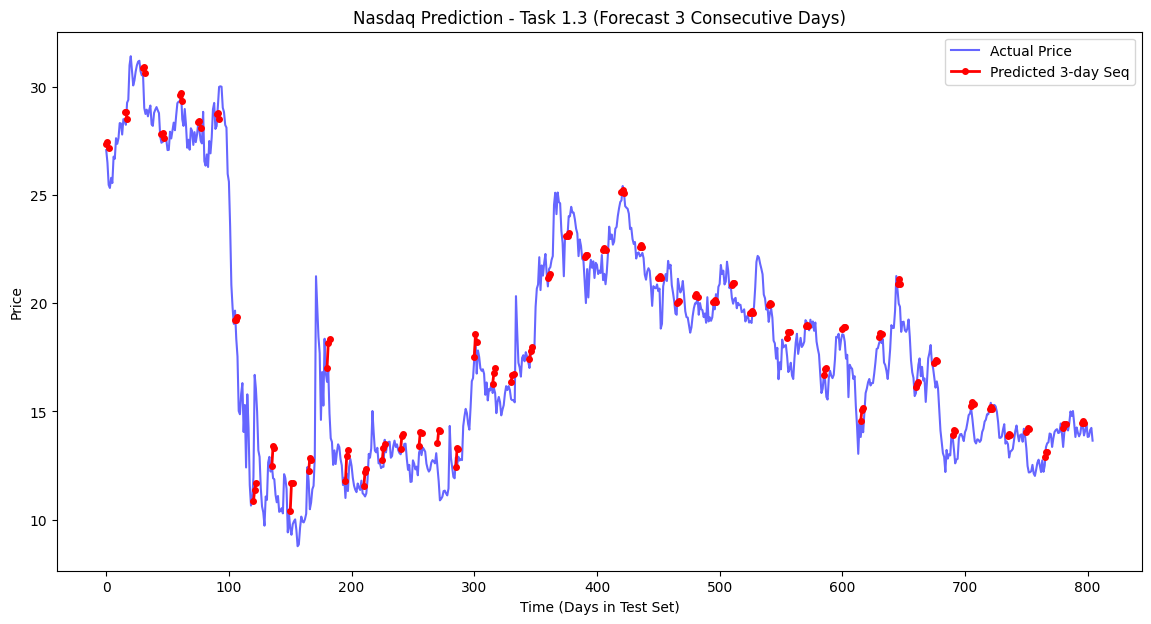

In [ ]:
# 1. Cấu hình k cho Task 1.3 (ví dụ dự báo chuỗi 3 ngày liên tiếp)
k_seq = 3

# 2. Tạo tập dữ liệu chuỗi (Sử dụng lại biến train/test từ 1.1)
trainX_seq, trainY_seq = create_dataset_sequence(train, time_step, target_idx=2, k=k_seq)
testX_seq, testY_seq = create_dataset_sequence(test, time_step, target_idx=2, k=k_seq)

# 3. Xây dựng mô hình chuỗi (Model_seq)
model_seq = Sequential()
model_seq.add(LSTM(50, input_shape=(time_step, 6)))

# ĐIỂM QUAN TRỌNG: Lớp Dense phải có số unit bằng số ngày k_seq
model_seq.add(Dense(k_seq))
model_seq.compile(loss='mean_squared_error', optimizer='adam')

# 4. Huấn luyện mô hình
# [Fix 1] Thêm validation_split và EarlyStopping
early_stop_seq3 = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)
model_seq.fit(trainX_seq, trainY_seq, epochs=100, batch_size=32,
              validation_split=0.1, callbacks=[early_stop_seq3], verbose=2)

# 5. Dự đoán và Đánh giá
y_pred_norm_seq = model_seq.predict(testX_seq)

# In ra MSE trên tập chuẩn hóa
print(f"MSE on the test set (Normalized, Sequence k={k_seq}): ", mean_squared_error(testY_seq, y_pred_norm_seq))

# 6. Khôi phục giá trị thực (De-normalization)
# Vì testY_seq và y_pred_norm_seq giờ là mảng 2D (N, k), ta cần flatten (.reshape(-1, 1))
# trước khi inverse_transform, sau đó reshape lại về dạng (N, k) ban đầu.
y_test_real_seq = target_scaler.inverse_transform(testY_seq.reshape(-1, 1)).reshape(-1, k_seq)
y_pred_real_seq = target_scaler.inverse_transform(y_pred_norm_seq.reshape(-1, 1)).reshape(-1, k_seq)
mae_seq  = mean_absolute_error(y_test_real_seq.flatten(), y_pred_real_seq.flatten())
rmse_seq = np.sqrt(mean_squared_error(y_test_real_seq.flatten(), y_pred_real_seq.flatten()))
mape_seq = np.mean(np.abs((y_test_real_seq - y_pred_real_seq) / y_test_real_seq)) * 100
print(f"MAE  on the test set (k={k_seq}): {mae_seq:.4f} USD")
print(f"RMSE on the test set (k={k_seq}): {rmse_seq:.4f} USD")
print(f"MAPE on the test set (k={k_seq}): {mape_seq:.2f}%")
# 7. Vẽ biểu đồ (Đặc thù cho chuỗi liên tiếp)
plt.figure(figsize=(14, 7))

# Vẽ đường giá thực tế liền mạch (chỉ lấy ngày đầu tiên của mỗi chuỗi Y để nối thành đường)
plt.plot(y_test_real_seq[:, 0], color='blue', label='Actual Price', alpha=0.6)

# Vẽ các đoạn dự báo chuỗi (cứ cách 15 ngày vẽ 1 đoạn để đồ thị không bị rối)
interval = 15
for i in range(0, len(y_pred_real_seq), interval):
    # Trục X cho k ngày
    x_axis = range(i, i + k_seq)

    # Gắn label cho đoạn đầu tiên để hiện trong chú thích (legend), các đoạn sau ẩn label
    if i == 0:
        plt.plot(x_axis, y_pred_real_seq[i], color='red', marker='o', markersize=4, linewidth=2, label=f'Predicted {k_seq}-day Seq')
    else:
        plt.plot(x_axis, y_pred_real_seq[i], color='red', marker='o', markersize=4, linewidth=2)

plt.title(f'Nasdaq Prediction - Task 1.3 (Forecast {k_seq} Consecutive Days)')
plt.xlabel('Time (Days in Test Set)')
plt.ylabel('Price')
plt.legend()
plt.show()

In [ ]:
def create_dataset_sequence(dataset, time_step=60, target_idx=2, k=7):
    dataX, dataY = [], []
    for i in range(len(dataset) - time_step - k + 1):
        # X: Lấy cửa sổ thời gian như bình thường (ví dụ 60 ngày)
        a = dataset[i:(i + time_step), :]
        dataX.append(a)

        # Y: Lấy một mảng liên tục k ngày tiếp theo
        dataY.append(dataset[i + time_step : i + time_step + k, target_idx])

    return np.array(dataX), np.array(dataY)

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


96/96 - 4s - 44ms/step - loss: 0.0251 - val_loss: 0.0019
Epoch 2/100
96/96 - 4s - 40ms/step - loss: 0.0013 - val_loss: 0.0018
Epoch 3/100
96/96 - 3s - 29ms/step - loss: 0.0012 - val_loss: 0.0017
Epoch 4/100
96/96 - 2s - 23ms/step - loss: 0.0012 - val_loss: 0.0016
Epoch 5/100
96/96 - 2s - 23ms/step - loss: 0.0011 - val_loss: 0.0014
Epoch 6/100
96/96 - 2s - 24ms/step - loss: 0.0011 - val_loss: 0.0015
Epoch 7/100
96/96 - 3s - 31ms/step - loss: 0.0010 - val_loss: 0.0012
Epoch 8/100
96/96 - 5s - 48ms/step - loss: 9.9667e-04 - val_loss: 0.0011
Epoch 9/100
96/96 - 2s - 24ms/step - loss: 9.9821e-04 - val_loss: 0.0011
Epoch 10/100
96/96 - 2s - 23ms/step - loss: 9.5822e-04 - val_loss: 0.0016
Epoch 11/100
96/96 - 2s - 23ms/step - loss: 9.7366e-04 - val_loss: 0.0011
Epoch 12/100
96/96 - 4s - 38ms/step - loss: 9.3726e-04 - val_loss: 0.0011
Epoch 13/100
96/96 - 4s - 42ms/step - loss: 9.3983e-04 - val_loss: 0.0010
Epoch 14/100
96/96 - 2s - 23ms/step - loss: 8.8803e-04 - val_loss: 0.0013
Epoch 15/100


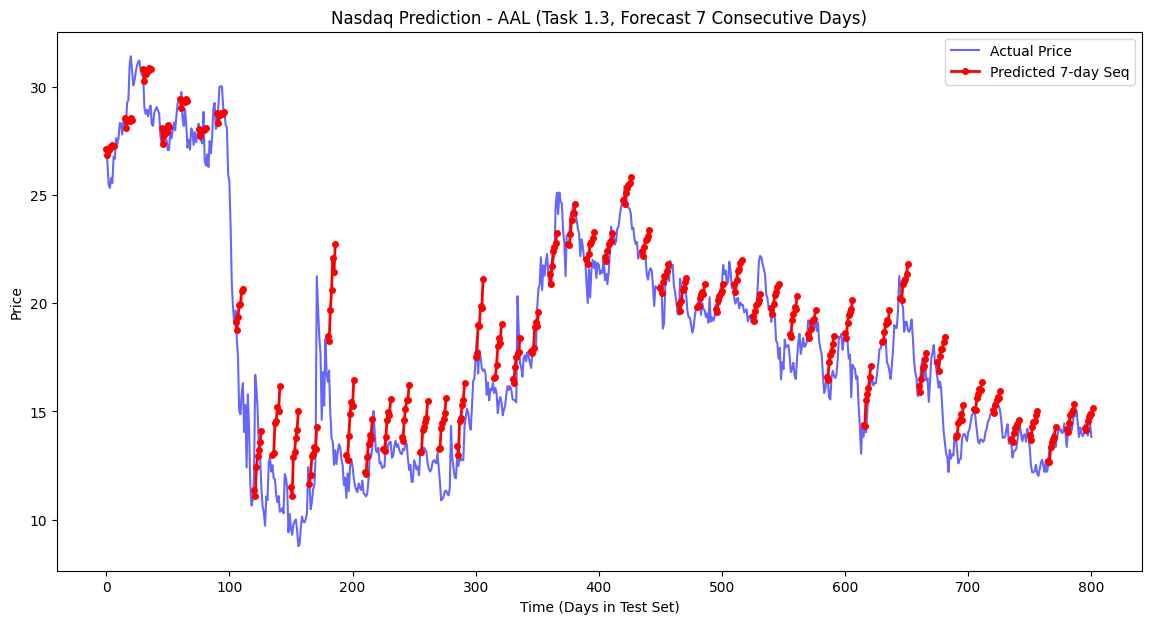

In [ ]:
# 1. Cấu hình k cho Task 1.3 (ví dụ dự báo chuỗi 7 ngày liên tiếp)
k_seq = 7

# 2. Tạo tập dữ liệu chuỗi (Sử dụng lại biến train từ 1.1)
trainX_seq, trainY_seq = create_dataset_sequence(train, time_step, target_idx=2, k=k_seq)
testX_seq, testY_seq = create_dataset_sequence(test, time_step, target_idx=2, k=k_seq)  # [Fix 4]

# 3. Xây dựng mô hình chuỗi (Model_seq)
model_seq = Sequential()
model_seq.add(LSTM(50, input_shape=(time_step, 6)))

# ĐIỂM QUAN TRỌNG: Lớp Dense phải có số unit bằng số ngày k_seq
model_seq.add(Dense(k_seq))
model_seq.compile(loss='mean_squared_error', optimizer='adam')

# 4. Huấn luyện mô hình
# [Fix 1] Thêm validation_split và EarlyStopping
early_stop_seq7 = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)
model_seq.fit(trainX_seq, trainY_seq, epochs=100, batch_size=32,
              validation_split=0.1, callbacks=[early_stop_seq7], verbose=2)

# 5. Dự đoán và Đánh giá
y_pred_norm_seq = model_seq.predict(testX_seq)

# In ra MSE trên tập chuẩn hóa
print(f"MSE on the test set (Normalized, Sequence k={k_seq}): ", mean_squared_error(testY_seq, y_pred_norm_seq))

# 6. Khôi phục giá trị thực (De-normalization)
# Vì testY_seq và y_pred_norm_seq giờ là mảng 2D (N, k), ta cần flatten (.reshape(-1, 1))
# trước khi inverse_transform, sau đó reshape lại về dạng (N, k) ban đầu.
y_test_real_seq = target_scaler.inverse_transform(testY_seq.reshape(-1, 1)).reshape(-1, k_seq)
y_pred_real_seq = target_scaler.inverse_transform(y_pred_norm_seq.reshape(-1, 1)).reshape(-1, k_seq)

# [Fix 6] Tính thêm MAE, RMSE, MAPE (flatten để tính trên toàn bộ k ngày)
mae_seq  = mean_absolute_error(y_test_real_seq.flatten(), y_pred_real_seq.flatten())
rmse_seq = np.sqrt(mean_squared_error(y_test_real_seq.flatten(), y_pred_real_seq.flatten()))
mape_seq = np.mean(np.abs((y_test_real_seq - y_pred_real_seq) / y_test_real_seq)) * 100
print(f"MAE  on the test set (k={k_seq}): {mae_seq:.4f} USD")
print(f"RMSE on the test set (k={k_seq}): {rmse_seq:.4f} USD")
print(f"MAPE on the test set (k={k_seq}): {mape_seq:.2f}%")

# 7. Vẽ biểu đồ (Đặc thù cho chuỗi liên tiếp)
plt.figure(figsize=(14, 7))

# Vẽ đường giá thực tế liền mạch (chỉ lấy ngày đầu tiên của mỗi chuỗi Y để nối thành đường)
plt.plot(y_test_real_seq[:, 0], color='blue', label='Actual Price', alpha=0.6)

# Vẽ các đoạn dự báo chuỗi (cứ cách 15 ngày vẽ 1 đoạn để đồ thị không bị rối)
interval = 15
for i in range(0, len(y_pred_real_seq), interval):
    # Trục X cho k ngày
    x_axis = range(i, i + k_seq)

    # Gắn label cho đoạn đầu tiên để hiện trong chú thích (legend), các đoạn sau ẩn label
    if i == 0:
        plt.plot(x_axis, y_pred_real_seq[i], color='red', marker='o', markersize=4, linewidth=2, label=f'Predicted {k_seq}-day Seq')
    else:
        plt.plot(x_axis, y_pred_real_seq[i], color='red', marker='o', markersize=4, linewidth=2)

plt.title(f'Nasdaq Prediction - AAL (Task 1.3, Forecast {k_seq} Consecutive Days)')  # [Fix 5] thêm AAL
plt.xlabel('Time (Days in Test Set)')
plt.ylabel('Price')
plt.legend()
plt.show()

# TASK 2

## 2.1

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

In [ ]:
# 1. Hàm tạo dataset đa biến (Dùng chung kiến trúc từ Task 1)
def create_dataset(dataset, time_step=1, target_idx=3):
    dataX, dataY = [], []
    for i in range(len(dataset) - time_step):
        # Lấy toàn bộ các cột (features) trong cửa sổ thời gian
        a = dataset[i:(i + time_step), :]
        dataX.append(a)
        # Lấy 1 cột mục tiêu để dự đoán
        dataY.append(dataset[i + time_step, target_idx])
    return np.array(dataX), np.array(dataY)

In [ ]:
# 2. Đọc dữ liệu Việt Nam (File SAM)
from google.colab import drive
drive.mount('/content/drive')
file_path = '/content/drive/MyDrive/data-vn-20230228/stock-historical-data/SAM-VNINDEX-History.csv'
df = pd.read_csv(file_path)

# MẸO NHỎ NHƯNG QUAN TRỌNG VỚI DATA VIỆT NAM:
# Dữ liệu tải từ các nguồn VN thường xếp ngày mới nhất ở trên cùng.
# Ta cần đảo ngược lại (từ cũ đến mới) để chuỗi thời gian đi đúng hướng.
if 'TradingDate' in df.columns:
    df['TradingDate'] = pd.to_datetime(df['TradingDate'])
    df = df.sort_values('TradingDate').reset_index(drop=True)

# Lọc 5 đặc trưng (Bỏ qua Adjusted Close vì file không có)
features_vn = ['Low', 'High', 'Open', 'Close', 'Volume']
dataset = df[features_vn].values
dataset = dataset.astype('float32')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# 3. Chia Train/Test (Chia TRƯỚC, Scale SAU để chống Data Leakage)
train_size = int(len(dataset) * 0.8)
test_size = len(dataset) - train_size
train, test = dataset[0:train_size,:], dataset[train_size:len(dataset),:]

In [ ]:
# 4. Chuẩn hóa dữ liệu (Scaling)
scaler = MinMaxScaler(feature_range=(0, 1))
train = scaler.fit_transform(train)
test = scaler.transform(test)

# Scaler riêng cho cột Target (Ở đây ta dự đoán 'Close' - nằm ở index 3 trong danh sách features_vn)
target_idx = 3
target_scaler = MinMaxScaler(feature_range=(0, 1))
target_scaler.fit(dataset[0:train_size, target_idx].reshape(-1, 1))

MinMaxScaler()

In [ ]:
# 5. Tạo tập dữ liệu Train/Test
time_step = 30
trainX, trainY = create_dataset(train, time_step, target_idx)
testX, testY = create_dataset(test, time_step, target_idx)

In [ ]:
# 6. Xây dựng mô hình LSTM (Sửa input_shape về 5 features)
model = Sequential()
# input_shape=(time_step, 5) vì dữ liệu VN lần này chỉ có 5 đặc trưng đầu vào
model.add(LSTM(50, input_shape=(time_step, 5)))
model.add(Dense(1))
model.compile(loss='mean_squared_error', optimizer='adam')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
# 7. Huấn luyện
# [Fix 1] Thêm validation_split và EarlyStopping để tránh overfit
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)
model.fit(trainX, trainY, epochs=100, batch_size=32,
          validation_split=0.1, callbacks=[early_stop], verbose=2)

Epoch 1/100
121/121 - 4s - 30ms/step - loss: 5.6782e-04 - val_loss: 8.8456e-05
Epoch 2/100
121/121 - 2s - 14ms/step - loss: 2.3521e-04 - val_loss: 7.3056e-05
Epoch 3/100
121/121 - 2s - 13ms/step - loss: 1.8012e-04 - val_loss: 9.6994e-05
Epoch 4/100
121/121 - 4s - 35ms/step - loss: 1.4651e-04 - val_loss: 4.8354e-05
Epoch 5/100
121/121 - 4s - 30ms/step - loss: 1.8131e-04 - val_loss: 9.7697e-05
Epoch 6/100
121/121 - 3s - 21ms/step - loss: 1.4890e-04 - val_loss: 4.2879e-05
Epoch 7/100
121/121 - 3s - 24ms/step - loss: 1.2222e-04 - val_loss: 5.1480e-05
Epoch 8/100
121/121 - 5s - 41ms/step - loss: 1.1795e-04 - val_loss: 5.5532e-05
Epoch 9/100
121/121 - 4s - 33ms/step - loss: 1.1157e-04 - val_loss: 1.2011e-04
Epoch 10/100
121/121 - 3s - 22ms/step - loss: 1.0947e-04 - val_loss: 6.6249e-05
Epoch 11/100
121/121 - 2s - 14ms/step - loss: 1.1766e-04 - val_loss: 3.6480e-05
Epoch 12/100
121/121 - 2s - 14ms/step - loss: 9.9198e-05 - val_loss: 3.3313e-05
Epoch 13/100
121/121 - 4s - 31ms/step - loss: 9.1

In [ ]:
# 8. Dự đoán và đưa về đơn vị giá thực tế
trainPredict = model.predict(trainX)
testPredict = model.predict(testX)

# Get prediction on the test data (Dự đoán trên tập test đã chuẩn hóa)
y_pred_norm = model.predict(testX)

# Tính và in ra MSE trên tập test (đã chuẩn hóa) theo đúng sample code
print("MSE on the test set: ", mean_squared_error(y_pred_norm, testY))
trainPredict = target_scaler.inverse_transform(trainPredict)
testPredict = target_scaler.inverse_transform(testPredict)

# [Fix 6] Tính thêm MAE, RMSE, MAPE trên giá thực tế
testY_real = target_scaler.inverse_transform(testY.reshape(-1, 1))
mae  = mean_absolute_error(testY_real, testPredict)
rmse = np.sqrt(mean_squared_error(testY_real, testPredict))
mape = np.mean(np.abs((testY_real - testPredict) / testY_real)) * 100
print(f"MAE  on the test set: {mae:.4f} USD")
print(f"RMSE on the test set: {rmse:.4f} USD")
print(f"MAPE on the test set: {mape:.2f}%")

135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
MSE on the test set:  0.00017724376812111586
MAE  on the test set: 226.6140 USD
RMSE on the test set: 386.3517 USD
MAPE on the test set: 1.95%


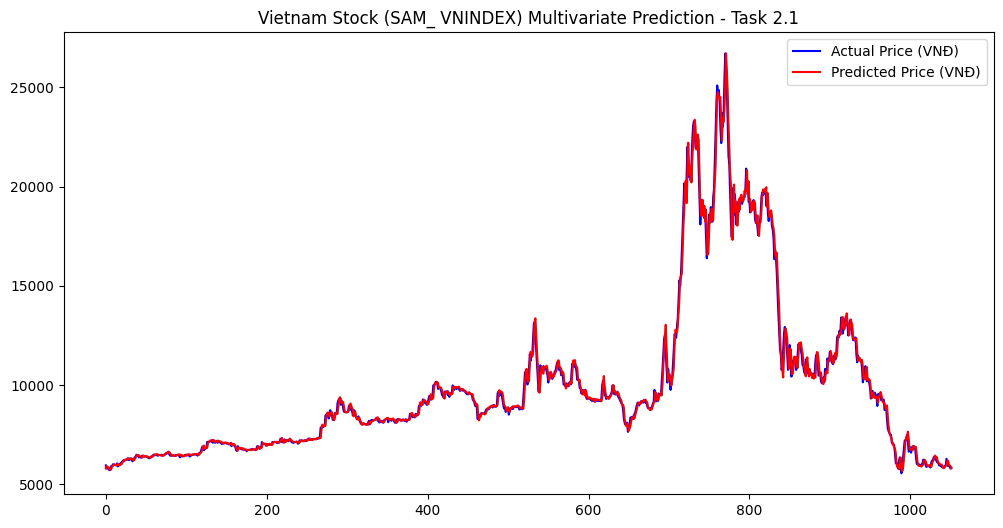

In [ ]:
import matplotlib.pyplot as plt

# 9. Vẽ biểu đồ so sánh
plt.figure(figsize=(12,6))
plt.plot(testY_real, label='Actual Price (VNĐ)', color='blue')
plt.plot(testPredict, label='Predicted Price (VNĐ)', color='red')
plt.title('Vietnam Stock (SAM_ VNINDEX) Multivariate Prediction - Task 2.1')
plt.legend()
plt.show()

## 2.2

In [ ]:
def create_dataset_kth_day(dataset, time_step=30, target_idx=3, k=3):
    """
    k: số ngày trong tương lai muốn dự đoán.
    Với dữ liệu VN, target_idx = 3 (cột Close).
    """
    dataX, dataY = [], []
    for i in range(len(dataset) - time_step - k + 1):
        # Lấy 30 ngày quá khứ, đủ 5 features (Low, High, Open, Close, Volume)
        a = dataset[i:(i + time_step), :]
        dataX.append(a)
        # Lấy giá trị của cột Target ở "k" ngày sau đó
        dataY.append(dataset[i + time_step + k - 1, target_idx])
    return np.array(dataX), np.array(dataY)

In [ ]:
# 1. Cấu hình k (Thay đổi thành 7 nếu muốn dự đoán ngày thứ 7)
k_days_ahead = 3

# 2. Tạo tập dữ liệu (Tái sử dụng 'train', 'test', 'time_step', 'target_idx' từ Task 2.1)
trainX_k, trainY_k = create_dataset_kth_day(train, time_step, target_idx, k=k_days_ahead)
testX_k, testY_k = create_dataset_kth_day(test, time_step, target_idx, k=k_days_ahead)

In [ ]:
# 3. Khởi tạo mô hình mới (Tên model_k để không ghi đè model của task 2.1)
model_k = Sequential()
model_k.add(LSTM(50, input_shape=(time_step, 5))) # 5 features của chứng khoán VN
model_k.add(Dense(1))
model_k.compile(loss='mean_squared_error', optimizer='adam')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
# 4. Huấn luyện
print(f"\n--- Đang huấn luyện dự đoán ngày thứ {k_days_ahead} (Mã SAM) ---")

# [Fix 1] Thêm validation_split và EarlyStopping để tránh overfit
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)
model_k.fit(trainX_k, trainY_k, epochs=100, batch_size=32,
          validation_split=0.1, callbacks=[early_stop], verbose=2)


--- Đang huấn luyện dự đoán ngày thứ 3 (Mã SAM) ---
Epoch 1/100
121/121 - 5s - 37ms/step - loss: 0.0018 - val_loss: 1.0663e-04
Epoch 2/100
121/121 - 3s - 21ms/step - loss: 4.3191e-04 - val_loss: 1.0089e-04
Epoch 3/100
121/121 - 2s - 14ms/step - loss: 3.8875e-04 - val_loss: 1.0592e-04
Epoch 4/100
121/121 - 2s - 14ms/step - loss: 3.8118e-04 - val_loss: 1.0076e-04
Epoch 5/100
121/121 - 2s - 14ms/step - loss: 3.5640e-04 - val_loss: 1.8967e-04
Epoch 6/100
121/121 - 3s - 21ms/step - loss: 3.6044e-04 - val_loss: 9.0977e-05
Epoch 7/100
121/121 - 3s - 22ms/step - loss: 3.3508e-04 - val_loss: 9.5686e-05
Epoch 8/100
121/121 - 3s - 22ms/step - loss: 3.2751e-04 - val_loss: 2.8406e-04
Epoch 9/100
121/121 - 3s - 21ms/step - loss: 3.0583e-04 - val_loss: 1.3749e-04
Epoch 10/100
121/121 - 2s - 13ms/step - loss: 2.9324e-04 - val_loss: 8.5463e-05
Epoch 11/100
121/121 - 2s - 13ms/step - loss: 2.9228e-04 - val_loss: 8.2821e-05
Epoch 12/100
121/121 - 3s - 21ms/step - loss: 2.6832e-04 - val_loss: 1.1818e-04


In [ ]:
# 5. Dự đoán và in MSE
y_pred_norm_k = model_k.predict(testX_k)
print(f"\nMSE on the test set (Normalized SAM Data, k={k_days_ahead}): ", mean_squared_error(testY_k, y_pred_norm_k))

33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step

MSE on the test set (Normalized SAM Data, k=3):  0.0007088013808242977


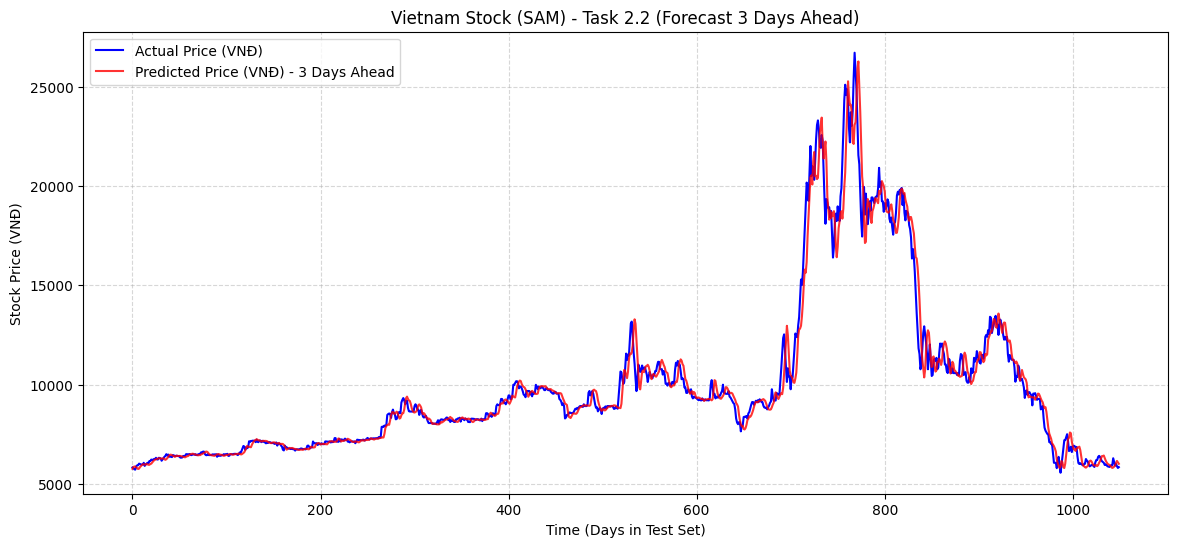

In [ ]:
# 6. Khôi phục giá trị thực tế (Tái sử dụng target_scaler từ Task 2.1)
y_test_rescaled_k = target_scaler.inverse_transform(testY_k.reshape(-1, 1))
y_pred_rescaled_k = target_scaler.inverse_transform(y_pred_norm_k)

# 7. Vẽ biểu đồ
plt.figure(figsize=(14,6))
plt.plot(y_test_rescaled_k, label='Actual Price (VNĐ)', color='blue', linewidth=1.5)
plt.plot(y_pred_rescaled_k, label=f'Predicted Price (VNĐ) - {k_days_ahead} Days Ahead', color='red', linewidth=1.5, alpha=0.8)
plt.title(f'Vietnam Stock (SAM) - Task 2.2 (Forecast {k_days_ahead} Days Ahead)')
plt.xlabel('Time (Days in Test Set)')
plt.ylabel('Stock Price (VNĐ)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [ ]:
mae  = mean_absolute_error(y_test_rescaled_k, y_pred_rescaled_k)
rmse = np.sqrt(mean_squared_error(y_test_rescaled_k, y_pred_rescaled_k))
mape = np.mean(np.abs((y_test_rescaled_k - y_pred_rescaled_k) / y_test_rescaled_k)) * 100
print(f"MAE  on the test set: {mae:.4f} USD")
print(f"RMSE on the test set: {rmse:.4f} USD")
print(f"MAPE on the test set: {mape:.2f}%")

MAE  on the test set: 416.1817 USD
RMSE on the test set: 772.6088 USD
MAPE on the test set: 3.55%


## 2.3

In [ ]:
# Hàm tạo dataset dự đoán một chuỗi k ngày liên tiếp
def create_dataset_sequence(dataset, time_step=30, target_idx=3, k=3):
    dataX, dataY = [], []
    for i in range(len(dataset) - time_step - k + 1):
        # Lấy X: Cửa sổ 30 ngày quá khứ, 5 features
        a = dataset[i:(i + time_step), :]
        dataX.append(a)

        # Lấy Y: MỘT CHUỖI k ngày liên tiếp sau cửa sổ X
        dataY.append(dataset[i + time_step : i + time_step + k, target_idx])

    return np.array(dataX), np.array(dataY)


--- Đang huấn luyện dự đoán ngày thứ 3 (Mã SAM) ---
Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


121/121 - 5s - 38ms/step - loss: 0.0034 - val_loss: 1.6078e-04
Epoch 2/100
121/121 - 3s - 21ms/step - loss: 3.8252e-04 - val_loss: 9.4842e-05
Epoch 3/100
121/121 - 2s - 14ms/step - loss: 3.5517e-04 - val_loss: 9.6321e-05
Epoch 4/100
121/121 - 2s - 13ms/step - loss: 3.1047e-04 - val_loss: 1.1068e-04
Epoch 5/100
121/121 - 2s - 14ms/step - loss: 2.8342e-04 - val_loss: 8.8941e-05
Epoch 6/100
121/121 - 3s - 21ms/step - loss: 2.7618e-04 - val_loss: 1.1960e-04
Epoch 7/100
121/121 - 2s - 13ms/step - loss: 2.7113e-04 - val_loss: 7.3616e-05
Epoch 8/100
121/121 - 4s - 30ms/step - loss: 2.3848e-04 - val_loss: 8.3273e-05
Epoch 9/100
121/121 - 2s - 19ms/step - loss: 2.5398e-04 - val_loss: 1.0388e-04
Epoch 10/100
121/121 - 2s - 16ms/step - loss: 2.4649e-04 - val_loss: 8.0958e-05
Epoch 11/100
121/121 - 2s - 14ms/step - loss: 2.1604e-04 - val_loss: 7.7275e-05
Epoch 12/100
121/121 - 2s - 14ms/step - loss: 2.2498e-04 - val_loss: 7.8178e-05
Epoch 13/100
121/121 - 2s - 13ms/step - loss: 2.2200e-04 - val_lo

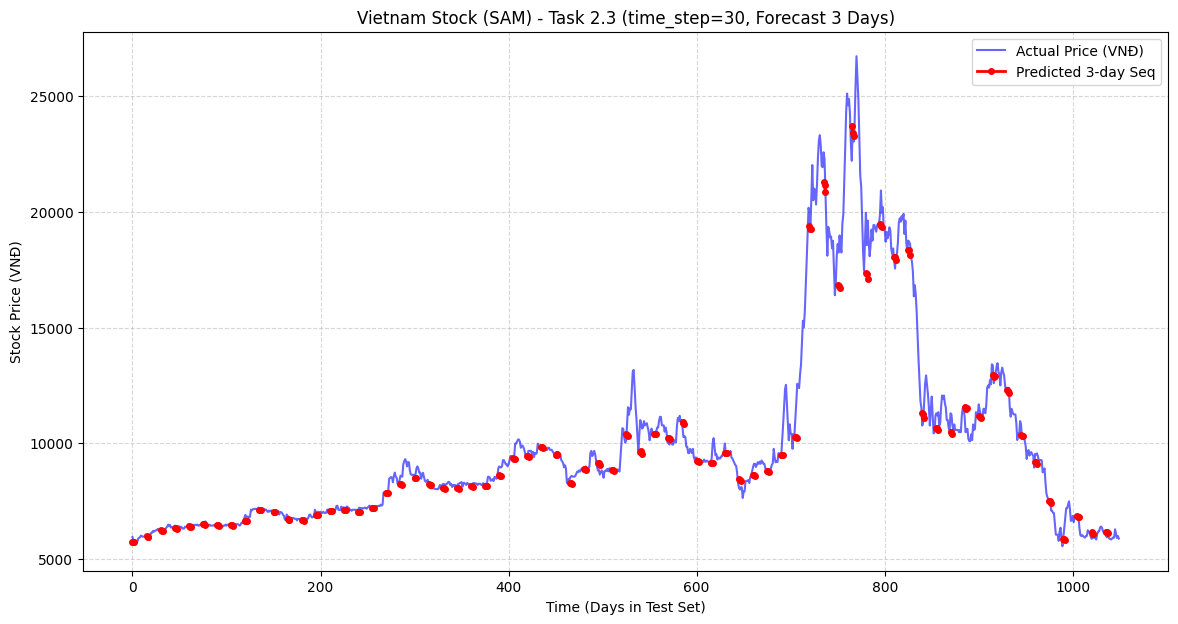

In [ ]:
# 1. Cập nhật cấu hình cửa sổ thời gian
time_step = 30  # Đã đổi thành 30 ngày theo yêu cầu
k_seq = 3       # Dự đoán chuỗi 3 ngày liên tiếp

# 2. Tạo tập dữ liệu chuỗi MỚI với time_step = 30
# (Vẫn tận dụng lại biến 'train' và 'test' đã chuẩn hóa từ Task 2.1)
trainX_seq, trainY_seq = create_dataset_sequence(train, time_step, target_idx=3, k=k_seq)
testX_seq, testY_seq = create_dataset_sequence(test, time_step, target_idx=3, k=k_seq)

# 3. Khởi tạo mô hình với input_shape mới
model_seq_vn = Sequential()
# model sẽ tự động nhận input_shape là (30, 5)
model_seq_vn.add(LSTM(50, input_shape=(time_step, 5)))
model_seq_vn.add(Dense(k_seq))
model_seq_vn.compile(loss='mean_squared_error', optimizer='adam')


# 4. Huấn luyện
print(f"\n--- Đang huấn luyện dự đoán ngày thứ {k_days_ahead} (Mã SAM) ---")

# [Fix 1] Thêm validation_split và EarlyStopping để tránh overfit
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)
model_seq_vn.fit(trainX_seq, trainY_seq, epochs=100, batch_size=32,
          validation_split=0.1, callbacks=[early_stop], verbose=2)
# 5. Dự đoán và in điểm MSE
y_pred_norm_seq = model_seq_vn.predict(testX_seq)
print(f"\nMSE on the test set (Normalized, time_step={time_step}, k={k_seq}): ", mean_squared_error(testY_seq, y_pred_norm_seq))

# 6. Khôi phục giá trị thực
y_test_real_seq = target_scaler.inverse_transform(testY_seq.reshape(-1, 1)).reshape(-1, k_seq)
y_pred_real_seq = target_scaler.inverse_transform(y_pred_norm_seq.reshape(-1, 1)).reshape(-1, k_seq)

# 7. Vẽ biểu đồ
plt.figure(figsize=(14, 7))

# Vẽ đường giá thực tế liền mạch
plt.plot(y_test_real_seq[:, 0], color='blue', label='Actual Price (VNĐ)', alpha=0.6, linewidth=1.5)

# Vẽ các đoạn rẽ nhánh dự báo
interval = 15
for i in range(0, len(y_pred_real_seq), interval):
    x_axis = range(i, i + k_seq)
    if i == 0:
        plt.plot(x_axis, y_pred_real_seq[i], color='red', marker='o', markersize=4, linewidth=2, label=f'Predicted {k_seq}-day Seq')
    else:
        plt.plot(x_axis, y_pred_real_seq[i], color='red', marker='o', markersize=4, linewidth=2)

plt.title(f'Vietnam Stock (SAM) - Task 2.3 (time_step={time_step}, Forecast {k_seq} Days)')
plt.xlabel('Time (Days in Test Set)')
plt.ylabel('Stock Price (VNĐ)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [ ]:
mae  = mean_absolute_error(y_test_real_seq, y_pred_real_seq)
rmse = np.sqrt(mean_squared_error(y_test_real_seq, y_pred_real_seq))
mape = np.mean(np.abs((y_test_real_seq - y_pred_real_seq) / y_test_real_seq)) * 100
print(f"MAE  on the test set: {mae:.4f} USD")
print(f"RMSE on the test set: {rmse:.4f} USD")
print(f"MAPE on the test set: {mape:.2f}%")

MAE  on the test set: 351.3621 USD
RMSE on the test set: 639.9943 USD
MAPE on the test set: 3.04%


# TASK 3

## 3.1

In [29]:
import os
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [30]:
import os
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# 1. Cấu hình đường dẫn (Cập nhật theo Google Drive của bạn)
base_path = '/content/drive/MyDrive/data-vn-20230228'
history_path = os.path.join(base_path, 'stock-historical-data')
finance_path = os.path.join(base_path, 'financial-ratio')
dividend_path = os.path.join(base_path, 'dividend-history')

# Giả sử chúng ta tiếp tục chọn file SAM (hoặc bạn có thể cho vòng lặp duyệt qua)
target_history_file = 'SAM-VNINDEX-History.csv'

# 2. Trích xuất tiền tố (base_name) để tìm các file liên quan
# Kết quả sẽ là 'SAM-VNINDEX'
base_name = target_history_file.replace('-History.csv', '')

print(f"--- Đang xử lý và hợp nhất dữ liệu cho mã: {base_name.split('-')[0]} ---")

# =====================================================================
# BƯỚC 1: XỬ LÝ DỮ LIỆU GIÁ (HISTORY)
# =====================================================================
df_price = pd.read_csv(os.path.join(history_path, target_history_file))

if 'TradingDate' in df_price.columns:
    df_price['TradingDate'] = pd.to_datetime(df_price['TradingDate'])
    df_price = df_price.sort_values('TradingDate').reset_index(drop=True)

# Feature Engineering cơ bản: Tính SMA và RSI
# 1. Tính toán Log Return (Thay đổi cốt lõi)
# Log return = ln(Close_t / Close_{t-1})
df_price['Log_Return'] = np.log(df_price['Close'] / df_price['Close'].shift(1))

# 2. Tính Log Return Volatility (Độ biến động) - Rất hữu ích cho LSTM
# Dùng độ lệch chuẩn của Log Return trong 14 ngày làm thước đo rủi ro
df_price['Volatility_14'] = df_price['Log_Return'].rolling(window=14).std()

df_price['SMA_14'] = df_price['Close'].rolling(window=14).mean()
# Khoảng cách tương đối giữa giá đóng cửa và đường SMA_14 (tính bằng %)
df_price['Dist_to_SMA'] = (df_price['Close'] - df_price['SMA_14']) / df_price['SMA_14']

# Nhớ cập nhật lại features_task3 ở BƯỚC 2:
# features_task3 = ['Open', 'High', 'Low', 'Close', 'Volume', 'Log_Return', 'Volatility_14', 'SMA_14', 'RSI_14', 'Dist_to_SMA']
# Có thể tính RSI dựa trên Log Return thay vì chênh lệch giá tuyệt đối (Tùy chọn)
delta = df_price['Close'].diff()
gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
rs = gain / loss
df_price['RSI_14'] = 100 - (100 / (1 + rs))

# =====================================================================
# BƯỚC 2: HỢP NHẤT CHỈ SỐ TÀI CHÍNH (FINANCIAL RATIO)
# =====================================================================
finance_file = f"{base_name}-Finance.csv"
finance_full_path = os.path.join(finance_path, finance_file)

if os.path.exists(finance_full_path):
    print(f"-> Đã tìm thấy file Tài chính: {finance_file}")
    df_fin = pd.read_csv(finance_full_path)

    # Hàm chuyển đổi Quý/Năm thành ngày cuối cùng của quý
    def get_quarter_end(row):
        try:
            q, y = int(row['quarter']), int(row['year'])
            if q == 1: return pd.Timestamp(y, 3, 31)
            elif q == 2: return pd.Timestamp(y, 6, 30)
            elif q == 3: return pd.Timestamp(y, 9, 30)
            elif q == 4: return pd.Timestamp(y, 12, 31)
        except:
            return pd.NaT

    if 'quarter' in df_fin.columns and 'year' in df_fin.columns:
        # Tạo cột ngày giả định để merge
        df_fin['ReportDate'] = df_fin.apply(get_quarter_end, axis=1)

        # Chỉ giữ lại các cột quan trọng (tránh làm rác dataframe)
        cols_to_keep = ['ReportDate', 'priceToEarning', 'roe', 'roa']
        # Lọc những cột thực sự tồn tại trong file
        cols_to_keep = [c for c in cols_to_keep if c in df_fin.columns]
        df_fin = df_fin[cols_to_keep]

        # Merge Left (Giữ nguyên chuỗi ngày giao dịch)
        df_price = pd.merge(df_price, df_fin, left_on='TradingDate', right_on='ReportDate', how='left')

        # FORWARD FILL: Ngày nào không có báo cáo thì lấy chỉ số của quý gần nhất
        for col in cols_to_keep:
            if col != 'ReportDate':
                df_price[col] = df_price[col].fillna(method='ffill')

        df_price.drop(columns=['ReportDate'], inplace=True, errors='ignore')
else:
    print(f"-> KHÔNG tìm thấy file Tài chính: {finance_file}")

# =====================================================================
# BƯỚC 3: HỢP NHẤT LỊCH SỬ CỔ TỨC (DIVIDEND HISTORY)
# =====================================================================
dividend_file = f"{base_name}-Dividend.csv"
dividend_full_path = os.path.join(dividend_path, dividend_file)

if os.path.exists(dividend_full_path):
    print(f"-> Đã tìm thấy file Cổ tức: {dividend_file}")
    df_div = pd.read_csv(dividend_full_path)

    if 'exerciseDate' in df_div.columns and 'cashDividendPercentage' in df_div.columns:
        # Chuyển đổi ngày cổ tức (Format thường là dd/mm/yy trong dữ liệu VN)
        df_div['exerciseDate'] = pd.to_datetime(df_div['exerciseDate'], format='%d/%m/%y', errors='coerce')

        # Nhóm dữ liệu (Trường hợp 1 ngày chia nhiều loại cổ tức)
        df_div_agg = df_div.groupby('exerciseDate')['cashDividendPercentage'].sum().reset_index()

        # Merge Left
        df_price = pd.merge(df_price, df_div_agg, left_on='TradingDate', right_on='exerciseDate', how='left')

        # FILL ZERO: Ngày nào không chia cổ tức thì điền số 0 (Không được dùng ffill ở đây)
        df_price['cashDividendPercentage'] = df_price['cashDividendPercentage'].fillna(0)
        df_price.drop(columns=['exerciseDate'], inplace=True, errors='ignore')
else:
    print(f"-> KHÔNG tìm thấy file Cổ tức: {dividend_file}")

# =====================================================================
# BƯỚC 4: LÀM SẠCH VÀ HIỂN THỊ
# =====================================================================
# Xóa các dòng NaN ở phần đầu do rolling window tạo ra
df_price.dropna(subset=['SMA_14', 'RSI_14'], inplace=True)

# Nếu phần đầu của mảng chưa có báo cáo tài chính nào, ta fill bằng 0 hoặc dùng bfill
df_price.fillna(method='bfill', inplace=True)

print("\n✅ HOÀN TẤT HỢP NHẤT! Bảng dữ liệu cuối cùng sẵn sàng cho mô hình LSTM:")
# Hiển thị các cột tiêu biểu để kiểm tra
display_cols = ['TradingDate', 'Close', 'SMA_14', 'RSI_14']
if 'priceToEarning' in df_price.columns: display_cols.append('priceToEarning')
if 'cashDividendPercentage' in df_price.columns: display_cols.append('cashDividendPercentage')

print(df_price[display_cols].tail(10).to_string())

--- Đang xử lý và hợp nhất dữ liệu cho mã: SAM ---
-> Đã tìm thấy file Tài chính: SAM-VNINDEX-Finance.csv
-> Đã tìm thấy file Cổ tức: SAM-VNINDEX-Dividend.csv

✅ HOÀN TẤT HỢP NHẤT! Bảng dữ liệu cuối cùng sẵn sàng cho mô hình LSTM:
     TradingDate   Close       SMA_14     RSI_14  priceToEarning  cashDividendPercentage
5400  2023-02-15  5900.0  6073.571429  32.954545            27.9                     0.0
5401  2023-02-16  5940.0  6043.571429  22.368421            27.9                     0.0
5402  2023-02-17  5930.0  6009.285714  16.666667            27.9                     0.0
5403  2023-02-20  6290.0  6004.285714  46.601942            27.9                     0.0
5404  2023-02-21  6100.0  5995.000000  44.036697            27.9                     0.0
5405  2023-02-22  5920.0  5979.285714  40.677966            27.9                     0.0
5406  2023-02-23  6000.0  5972.142857  45.901639            27.9                     0.0
5407  2023-02-24  5890.0  5960.000000  43.410853         

In [31]:
df_price

,Unnamed: 0,Open,High,Low,Close,Volume,TradingDate,Log_Return,Volatility_14,SMA_14,Dist_to_SMA,RSI_14,priceToEarning,roe,roa,cashDividendPercentage
13,13,1777.0,1777.0,1777.0,1777.0,165100,2001-02-09,0.018745,0.010793,1589.785714,0.117761,100.000000,43.9,0.261,0.126,0.0
14,14,1744.0,1744.0,1744.0,1744.0,44900,2001-02-12,-0.018745,0.010793,1612.642857,0.081455,91.450777,43.9,0.261,0.126,0.0
15,15,1710.0,1710.0,1710.0,1710.0,1500,2001-02-14,-0.019688,0.014074,1631.285714,0.048253,83.037975,43.9,0.261,0.126,0.0
16,16,1676.0,1676.0,1676.0,1676.0,300,2001-02-16,-0.020083,0.016330,1645.714286,0.018403,75.000000,43.9,0.261,0.126,0.0
17,17,1647.0,1647.0,1647.0,1647.0,500,2001-02-19,-0.017455,0.017441,1655.928571,-0.005392,67.741935,43.9,0.261,0.126,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5405,5405,6000.0,6090.0,5920.0,5920.0,637859,2023-02-22,-0.029952,0.021388,5979.285714,-0.009915,40.677966,27.9,0.034,0.016,0.0
5406,5406,5970.0,6000.0,5760.0,6000.0,629185,2023-02-23,0.013423,0.021768,5972.142857,0.004665,45.901639,27.9,0.034,0.016,0.0
5407,5407,6000.0,6000.0,5860.0,5890.0,264831,2023-02-24,-0.018503,0.022224,5960.000000,-0.011745,43.410853,27.9,0.034,0.016,0.0
5408,5408,5880.0,5880.0,5700.0,5800.0,395946,2023-02-27,-0.015398,0.022072,5949.285714,-0.025093,44.094488,27.9,0.034,0.016,0.0


--- BƯỚC 1: GẮN NHÃN TÍN HIỆU (CHỈ TẬP TRUNG VÀO 'MUA') ---
Phân bổ nhãn (0 = Không Mua, 1 = Mua):
Buy_Signal
0    3831
1    1561
Name: count, dtype: int64

--- BƯỚC 2: CHUẨN BỊ DỮ LIỆU (CHỐNG DATA LEAKAGE) ---

--- BƯỚC 3: XÂY DỰNG MÔ HÌNH NHẬN DIỆN MUA (PROBABILITY OUTPUT) ---
Sử dụng trọng số thủ công: {0: 1.0, 1: 2.0}
Epoch 1/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 8s 28ms/step - accuracy: 0.5338 - loss: 1.7379 - val_accuracy: 0.6698 - val_loss: 1.2705
Epoch 2/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.5488 - loss: 1.6617 - val_accuracy: 0.6698 - val_loss: 1.2517
Epoch 3/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.5428 - loss: 1.6205 - val_accuracy: 0.6628 - val_loss: 1.2424
Epoch 4/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.5695 - loss: 1.5582 - val_accuracy: 0.6140 - val_loss: 1.2450
Epoch 5/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.5762 - loss: 1.5158 - val_accuracy: 0.5907 - val_loss: 1.2418
Epoch 6/100
121/121 ━━━━━━

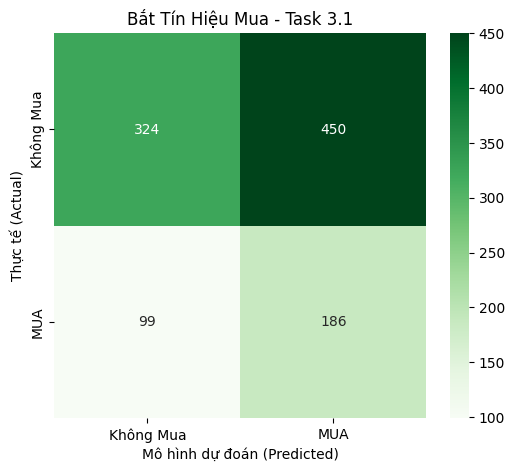


Demo: Xác suất báo MUA cho 5 ngày giao dịch gần nhất trong tập Test:
Ngày 1: Có 33.02% khả năng sinh lời -> Khuyến nghị: BỎ QUA
Ngày 2: Có 32.62% khả năng sinh lời -> Khuyến nghị: BỎ QUA
Ngày 3: Có 30.11% khả năng sinh lời -> Khuyến nghị: BỎ QUA
Ngày 4: Có 29.36% khả năng sinh lời -> Khuyến nghị: BỎ QUA
Ngày 5: Có 29.95% khả năng sinh lời -> Khuyến nghị: BỎ QUA


In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

print("--- BƯỚC 1: GẮN NHÃN TÍN HIỆU (CHỈ TẬP TRUNG VÀO 'MUA') ---")

# 1. Cấu hình quy tắc sinh lời cho lệnh MUA
k_days = 5         # Nắm giữ 3 ngày
threshold = 0.02   # Kỳ vọng lãi > 2%

# 2. Tính lợi nhuận tương lai
df_price['Future_Close'] = df_price['Close'].shift(-k_days)
df_price['Return'] = (df_price['Future_Close'] - df_price['Close']) / df_price['Close']

# 3. Gắn nhãn NHỊ PHÂN (Binary Labeling)
# Nếu Return > 2% -> Nhãn 1 (MUA). Tất cả các trường hợp còn lại (Giảm hoặc Đi ngang) -> Nhãn 0 (KHÔNG MUA)
df_price['Buy_Signal'] = np.where(df_price['Return'] >= threshold, 1, 0)

# Bỏ các dòng NaN ở cuối
df_price.dropna(subset=['Buy_Signal', 'Future_Close', 'Return'], inplace=True)

print("Phân bổ nhãn (0 = Không Mua, 1 = Mua):")
print(df_price['Buy_Signal'].value_counts())


print("\n--- BƯỚC 2: CHUẨN BỊ DỮ LIỆU (CHỐNG DATA LEAKAGE) ---")

# Cập nhật features (bao gồm cả MACD nếu bạn đã tính ở bước trước)
features_task3 = ['Open', 'High', 'Low', 'Close', 'Volume', 'SMA_14', 'RSI_14', 'Log_Return', 'Volatility_14']
if 'priceToEarning' in df_price.columns: features_task3.append('priceToEarning')
if 'cashDividendPercentage' in df_price.columns: features_task3.append('cashDividendPercentage')
if 'MACD' in df_price.columns: features_task3.extend(['MACD', 'Signal_Line'])

dataset_X = df_price[features_task3].values
dataset_Y = df_price['Buy_Signal'].values

# Chia Train/Test TRƯỚC KHI Scale
train_size = int(len(dataset_X) * 0.8)
train_X_raw, test_X_raw = dataset_X[:train_size], dataset_X[train_size:]
train_Y_raw, test_Y_raw = dataset_Y[:train_size], dataset_Y[train_size:]

# Chuẩn hóa X
from sklearn.preprocessing import StandardScaler

# Chuẩn hóa X (Thay thế MinMaxScaler)
scaler_X = StandardScaler()
train_X_scaled = scaler_X.fit_transform(train_X_raw)
test_X_scaled = scaler_X.transform(test_X_raw)

# Hàm tạo Window
def create_dataset_binary(X, Y, time_step=20):
    dataX, dataY = [], []
    for i in range(len(X) - time_step):
        dataX.append(X[i:(i + time_step), :])
        dataY.append(Y[i + time_step])
    return np.array(dataX), np.array(dataY)

time_step = 20
X_train, Y_train = create_dataset_binary(train_X_scaled, train_Y_raw, time_step)
X_test, Y_test = create_dataset_binary(test_X_scaled, test_Y_raw, time_step)

# KHÔNG CẦN One-hot Encoding nữa vì đây là Binary Classification!


print("\n--- BƯỚC 3: XÂY DỰNG MÔ HÌNH NHẬN DIỆN MUA (PROBABILITY OUTPUT) ---")

# Tính toán Class Weights cho 2 class (0 và 1) để ép mô hình chú ý vào tín hiệu Mua (1)
class_weight_dict = {
    0: 1.0,
    1: 2.0
}
print(f"Sử dụng trọng số thủ công: {class_weight_dict}")

from tensorflow.keras.regularizers import l2

model_buy = Sequential()
# Thu nhỏ LSTM và thêm L2 penalty
model_buy.add(LSTM(32, return_sequences=True, input_shape=(time_step, len(features_task3)), kernel_regularizer=l2(0.01)))
model_buy.add(BatchNormalization())
model_buy.add(Dropout(0.5)) # Dropout cao hơn để model không phụ thuộc vào 1 node nào

model_buy.add(LSTM(16, kernel_regularizer=l2(0.01)))
model_buy.add(BatchNormalization())
model_buy.add(Dropout(0.5))

model_buy.add(Dense(8, activation='relu'))
model_buy.add(Dense(1, activation='sigmoid'))

# Hàm Loss thay đổi thành 'binary_crossentropy'
optimizer = Adam(learning_rate=0.0001)
model_buy.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True, verbose=1)

history = model_buy.fit(
    X_train, Y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    class_weight=class_weight_dict,
    verbose=1
)


print("\n--- BƯỚC 4: ĐÁNH GIÁ & XUẤT XÁC SUẤT MUA ---")

# 1. Lấy Xác suất (Probability) từ mô hình
predicted_probabilities = model_buy.predict(X_test).flatten()

# CHỈNH SỬA C: Đoạn code tìm Threshold tối ưu
from sklearn.metrics import f1_score

best_f1 = 0
best_threshold = 0.5

# Thử nghiệm các ngưỡng từ 40% đến 80% (mỗi bước tăng 5%)
for threshold in np.arange(0.4, 0.85, 0.05):
    y_pred_temp = (predicted_probabilities > threshold).astype(int)
    f1 = f1_score(Y_test, y_pred_temp, average='binary')
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = threshold

print(f"\n=> VÒNG LẶP TÌM NGƯỠNG: Ngưỡng tối ưu nhất được chọn là: {best_threshold:.2f}")

# 2. Áp dụng ngưỡng TỐI ƯU vừa tìm được (thay vì ngưỡng 0.5 cố định)
Y_pred_binary = (predicted_probabilities > best_threshold).astype(int)

# In Report chi tiết (Sẽ báo cáo dựa trên best_threshold)
print("\nClassification Report (Binary - Buying Signal):")
print(classification_report(Y_test, Y_pred_binary, target_names=['Không Mua (0)', 'MUA (1)']))

# ... (Phần vẽ Confusion Matrix giữ nguyên) ...

# Vẽ Confusion Matrix
cm = confusion_matrix(Y_test, Y_pred_binary)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=['Không Mua', 'MUA'], yticklabels=['Không Mua', 'MUA'])
plt.title('Bắt Tín Hiệu Mua - Task 3.1')
plt.ylabel('Thực tế (Actual)')
plt.xlabel('Mô hình dự đoán (Predicted)')
plt.show()

# Hiển thị demo Xác suất của 5 ngày cuối cùng
print("\nDemo: Xác suất báo MUA cho 5 ngày giao dịch gần nhất trong tập Test:")
for i in range(1, 6):
    prob = predicted_probabilities[-i] * 100
    decision = "MUA" if prob > 50 else "BỎ QUA"
    print(f"Ngày {i}: Có {prob:.2f}% khả năng sinh lời -> Khuyến nghị: {decision}")

## 3.2


--- BƯỚC 5: GẮN NHÃN TÍN HIỆU BÁN (TASK 3.2) ---
Phân bổ nhãn (0 = Không Bán, 1 = BÁN):
Sell_Signal
0    4105
1    1176
Name: count, dtype: int64

--- BƯỚC 6: CHUẨN BỊ DỮ LIỆU ---

--- BƯỚC 7: XÂY DỰNG MÔ HÌNH NHẬN DIỆN BÁN ---
Sử dụng trọng số thủ công: {0: 1.0, 1: 2.0}
Epoch 1/100
119/119 ━━━━━━━━━━━━━━━━━━━━ 13s 21ms/step - accuracy: 0.4375 - loss: 1.0307 - val_accuracy: 0.7862 - val_loss: 0.7031
Epoch 2/100
119/119 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.5242 - loss: 0.9489 - val_accuracy: 0.7838 - val_loss: 0.6494
Epoch 3/100
119/119 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - accuracy: 0.5781 - loss: 0.9008 - val_accuracy: 0.7672 - val_loss: 0.6248
Epoch 4/100
119/119 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.5945 - loss: 0.8894 - val_accuracy: 0.7648 - val_loss: 0.6129
Epoch 5/100
119/119 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.6318 - loss: 0.8585 - val_accuracy: 0.7601 - val_loss: 0.6095
Epoch 6/100
119/119 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.6421 - l

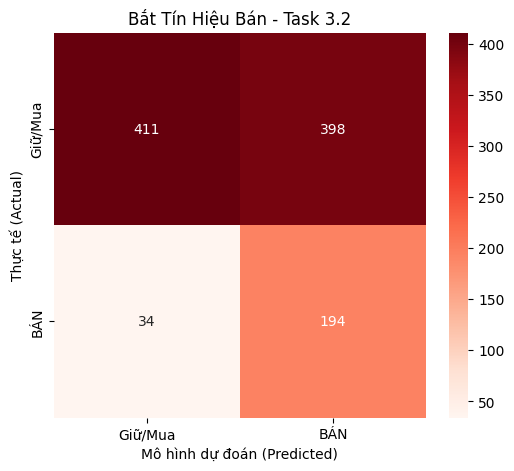

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, f1_score, recall_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l2
from sklearn.utils import class_weight # Import class_weight

print("\n--- BƯỚC 5: GẮN NHÃN TÍN HIỆU BÁN (TASK 3.2) ---")
# --- TÍNH TOÁN BOLLINGER BANDS (BB) ---
df_price['SMA_20'] = df_price['Close'].rolling(window=20).mean()
df_price['STD_20'] = df_price['Close'].rolling(window=20).std()
df_price['Upper_Band'] = df_price['SMA_20'] + (df_price['STD_20'] * 2)
df_price['Lower_Band'] = df_price['SMA_20'] - (df_price['STD_20'] * 2)

df_price['Dist_to_UB'] = (df_price['Close'] - df_price['Upper_Band']) / df_price['Upper_Band']
df_price['BB_Percent_B'] = (df_price['Close'] - df_price['Lower_Band']) / (df_price['Upper_Band'] - df_price['Lower_Band'])

# SỬA LẠI DÒNG DROPNA:
df_price.dropna(subset=['SMA_14', 'RSI_14', 'SMA_20', 'Upper_Band'], inplace=True)
# 1. Cấu hình quy tắc rủi ro cho lệnh BÁN
k_days = 5         # Tầm nhìn 5 ngày tới
threshold = -0.03  # Cảnh báo giảm giá sâu hơn 3% (LƯU Ý DẤU ÂM)

# 2. Tính lợi nhuận tương lai
df_price['Future_Close'] = df_price['Close'].shift(-k_days)
df_price['Return'] = (df_price['Future_Close'] - df_price['Close']) / df_price['Close']

# 3. Gắn nhãn BÁN
# Nếu Return <= -3% -> Giá sắp sập sâu, phải BÁN (Nhãn 1). Còn lại GIỮ/MUA (Nhãn 0)
df_price['Sell_Signal'] = np.where(df_price['Return'] <= threshold, 1, 0)

# Bỏ các dòng NaN ở cuối do shift tạo ra
df_price.dropna(subset=['Sell_Signal', 'Future_Close', 'Return'], inplace=True)

print("Phân bổ nhãn (0 = Không Bán, 1 = BÁN):")
print(df_price['Sell_Signal'].value_counts())


print("\n--- BƯỚC 6: CHUẨN BỊ DỮ LIỆU ---")

# Cập nhật danh sách features (Đã bao gồm các feature mới)
features_task3 = ['Open', 'High', 'Low', 'Volume', 'Log_Return', 'Volatility_14', 'SMA_14', 'RSI_14', 'Dist_to_SMA', 'Dist_to_UB', 'BB_Percent_B']
if 'priceToEarning' in df_price.columns: features_task3.append('priceToEarning')
if 'cashDividendPercentage' in df_price.columns: features_task3.append('cashDividendPercentage')

dataset_X = df_price[features_task3].values
dataset_Y = df_price['Sell_Signal'].values

# Chia Train/Test TRƯỚC KHI Scale (Tỷ lệ 80/20)
train_size = int(len(dataset_X) * 0.8)
train_X_raw, test_X_raw = dataset_X[:train_size], dataset_X[train_size:]
train_Y_raw, test_Y_raw = dataset_Y[:train_size], dataset_Y[train_size:]

# Chuẩn hóa bằng StandardScaler (Tốt hơn cho Log Return và Dist_to_SMA)
scaler_X = StandardScaler()
train_X_scaled = scaler_X.fit_transform(train_X_raw)
test_X_scaled = scaler_X.transform(test_X_raw)

# Rút ngắn Window (time_step) xuống 20 ngày (Khoảng 1 tháng giao dịch) để bắt tín hiệu ngắn hạn nhạy hơn
def create_dataset_binary(X, Y, time_step=20):
    dataX, dataY = [], []
    for i in range(len(X) - time_step):
        dataX.append(X[i:(i + time_step), :])
        dataY.append(Y[i + time_step])
    return np.array(dataX), np.array(dataY)

time_step = 20
X_train, Y_train = create_dataset_binary(train_X_scaled, train_Y_raw, time_step)
X_test, Y_test = create_dataset_binary(test_X_scaled, test_Y_raw, time_step)


print("\n--- BƯỚC 7: XÂY DỰNG MÔ HÌNH NHẬN DIỆN BÁN ---")
class_weight_dict = {
    0: 1.0,
    1: 2.0  # Chỉ phạt gấp rưỡi thôi để mô hình không bị "hoảng loạn"
}
print(f"Sử dụng trọng số thủ công: {class_weight_dict}")

model_sell = Sequential()
model_sell.add(LSTM(32, return_sequences=True, input_shape=(time_step, len(features_task3)), kernel_regularizer=l2(0.001)))
model_sell.add(BatchNormalization())
model_sell.add(Dropout(0.3))

model_sell.add(LSTM(16, kernel_regularizer=l2(0.001)))
model_sell.add(BatchNormalization())
model_sell.add(Dropout(0.3))

model_sell.add(Dense(8, activation='relu'))
model_sell.add(Dense(1, activation='sigmoid'))

optimizer = Adam(learning_rate=0.0001)
model_sell.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=['accuracy'])

# Siết Early Stopping
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)

history = model_sell.fit(
    X_train, Y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    class_weight=class_weight_dict,
    verbose=1
)

print("\n--- BƯỚC 8: ĐÁNH GIÁ & TÌM NGƯỠNG BÁN TỐI ƯU ---")

predicted_probabilities = model_sell.predict(X_test).flatten()
from sklearn.metrics import f1_score, recall_score, precision_score # Thêm precision_score vào import

# ...
best_f1 = 0
best_threshold = 0.5
best_recall = 0

for threshold in np.arange(0.20, 0.8, 0.02): # Nâng mức bắt đầu lên 0.35
    y_pred_temp = (predicted_probabilities > threshold).astype(int)

    if sum(y_pred_temp) > 0:
        f1 = f1_score(Y_test, y_pred_temp, average='binary')
        rec = recall_score(Y_test, y_pred_temp, average='binary', zero_division=0)
        prec = precision_score(Y_test, y_pred_temp, average='binary', zero_division=0) # Tính thêm Precision

        # ĐIỀU KIỆN MỚI: Dù Recall có cao đến mấy, Precision cũng phải > 0.40 (Tức là báo Bán 10 lần phải đúng ít nhất 4 lần)
        if f1 > best_f1 and rec >= 0.25 and prec >= 0.25:
            best_f1 = f1
            best_threshold = threshold
            best_recall = rec

if best_f1 == 0:
    best_threshold = 0.30 # Trả về ngưỡng cao để an toàn nếu không thỏa mãn điều kiện
    print("\n=> Không tìm thấy ngưỡng thỏa mãn (đủ Precision/Recall), dùng mặc định: 0.60")
else:
    print(f"\n=> Ngưỡng BÁN tối ưu nhất được chọn là: {best_threshold:.2f} (F1: {best_f1:.3f}, Recall: {best_recall:.3f})")

Y_pred_binary = (predicted_probabilities > best_threshold).astype(int)

print("\nClassification Report (Binary - Selling Signal):")
print(classification_report(Y_test, Y_pred_binary, target_names=['Giữ/Mua (0)', 'BÁN NGAY (1)']))

# Vẽ Confusion Matrix
cm = confusion_matrix(Y_test, Y_pred_binary)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', xticklabels=['Giữ/Mua', 'BÁN'], yticklabels=['Giữ/Mua', 'BÁN'])
plt.title('Bắt Tín Hiệu Bán - Task 3.2')
plt.ylabel('Thực tế (Actual)')
plt.xlabel('Mô hình dự đoán (Predicted)')
plt.show()